# LeetCode #162: Find Peak Element

https://leetcode.com/problems/find-peak-element/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Optimal: Binary Search on Gradient ★** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Scan until nums[i] > nums[i+1]. Works in $O(n)$ but doesn't leverage the implicit "infinite" boundaries.

### Optimal: Binary Search on Gradient ★
If `nums[mid] < nums[mid+1]`, the slope is ascending — a peak must exist to the right (the array must decrease eventually, given -∞ boundaries). So set `lo = mid + 1`. Otherwise the slope is flat or descending and a peak is at `mid` or to its left — set `hi = mid`. Loop until `lo == hi`, which is the peak index.

**Constraints:**
* 1 <= nums.length <= 1000
* -2^31 <= nums[i] <= 2^31 - 1
* nums[i] != nums[i + 1] for all valid i
* nums[-1] = nums[n] = -∞ (conceptually)


## Solutions

### C#

In [ ]:
public int FindPeakElement(int[] nums) {
    int lo = 0, hi = nums.Length - 1;
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        // Ascending slope means peak is to the right
        if (nums[mid] < nums[mid + 1]) lo = mid + 1;
        else hi = mid;  // Descending or flat means peak is at mid or left
    }
    return lo;
}


### Python

In [ ]:
def findPeakElement(self, nums: list[int]) -> int:
    lo, hi = 0, len(nums) - 1
    while lo < hi:
        mid = lo + (hi - lo) // 2
        # Ascending slope means peak is to the right
        if nums[mid] < nums[mid + 1]:
            lo = mid + 1
        else:
            hi = mid  # Descending or flat means peak is at mid or left
    return lo


### Go

In [ ]:
func findPeakElement(nums []int) int {
    lo, hi := 0, len(nums)-1
    for lo < hi {
        mid := lo + (hi-lo)/2
        // Ascending slope means peak is to the right
        if nums[mid] < nums[mid+1] {
            lo = mid + 1
        } else {
            hi = mid  // Descending or flat means peak is at mid or left
        }
    }
    return lo
}


### Rust

In [ ]:
pub fn find_peak_element(nums: Vec<i32>) -> i32 {
    let (mut lo, mut hi) = (0usize, nums.len() - 1);
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        // Ascending slope means peak is to the right
        if nums[mid] < nums[mid + 1] {
            lo = mid + 1;
        } else {
            hi = mid;  // Descending or flat means peak is at mid or left
        }
    }
    lo as i32
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [1, 2, 3, 1]
lo=0,hi=3. mid=1(2)<nums[2]=3 → lo=2. mid=2(3)>nums[3]=1 → hi=2. lo=hi=2 → return 2. Index 2 holds the peak value 3.

**2. Slightly Complex**
**Input:** nums = [1, 2, 1, 3, 5, 6, 4]
Multiple peaks (indices 1, 5). mid=3(3)<nums[4]=5 → lo=4. mid=5(6)>nums[6]=4 → hi=5. lo=hi=5 → return 5. Any valid peak index is accepted.

**3. Edge Case: Time Factor**
**Input:** nums = [1, 2, 3, ..., 1000] (strictly ascending)
Every mid satisfies nums[mid]<nums[mid+1] → lo=mid+1. Peak is at index 999. Depth: $\lceil \log_2 1000 \rceil = 10$ iterations.

**4. Edge Case: Space Factor**
**Input:** nums = [1]
lo=hi=0, loop never executes, return 0. A single element is trivially a peak (both -∞ neighbors). $O(1)$ space — just lo, hi, mid.

**5. Almost-Impossible but Plausible**
**Input:** nums = [2^31-1, -(2^31)] (INT_MAX then INT_MIN)
lo=0,hi=1. mid=0: nums[0]=INT_MAX > nums[1]=INT_MIN → hi=0. return 0. The comparison `nums[mid] < nums[mid+1]` is a straightforward signed integer comparison — no overflow because we compare stored values, not compute differences.


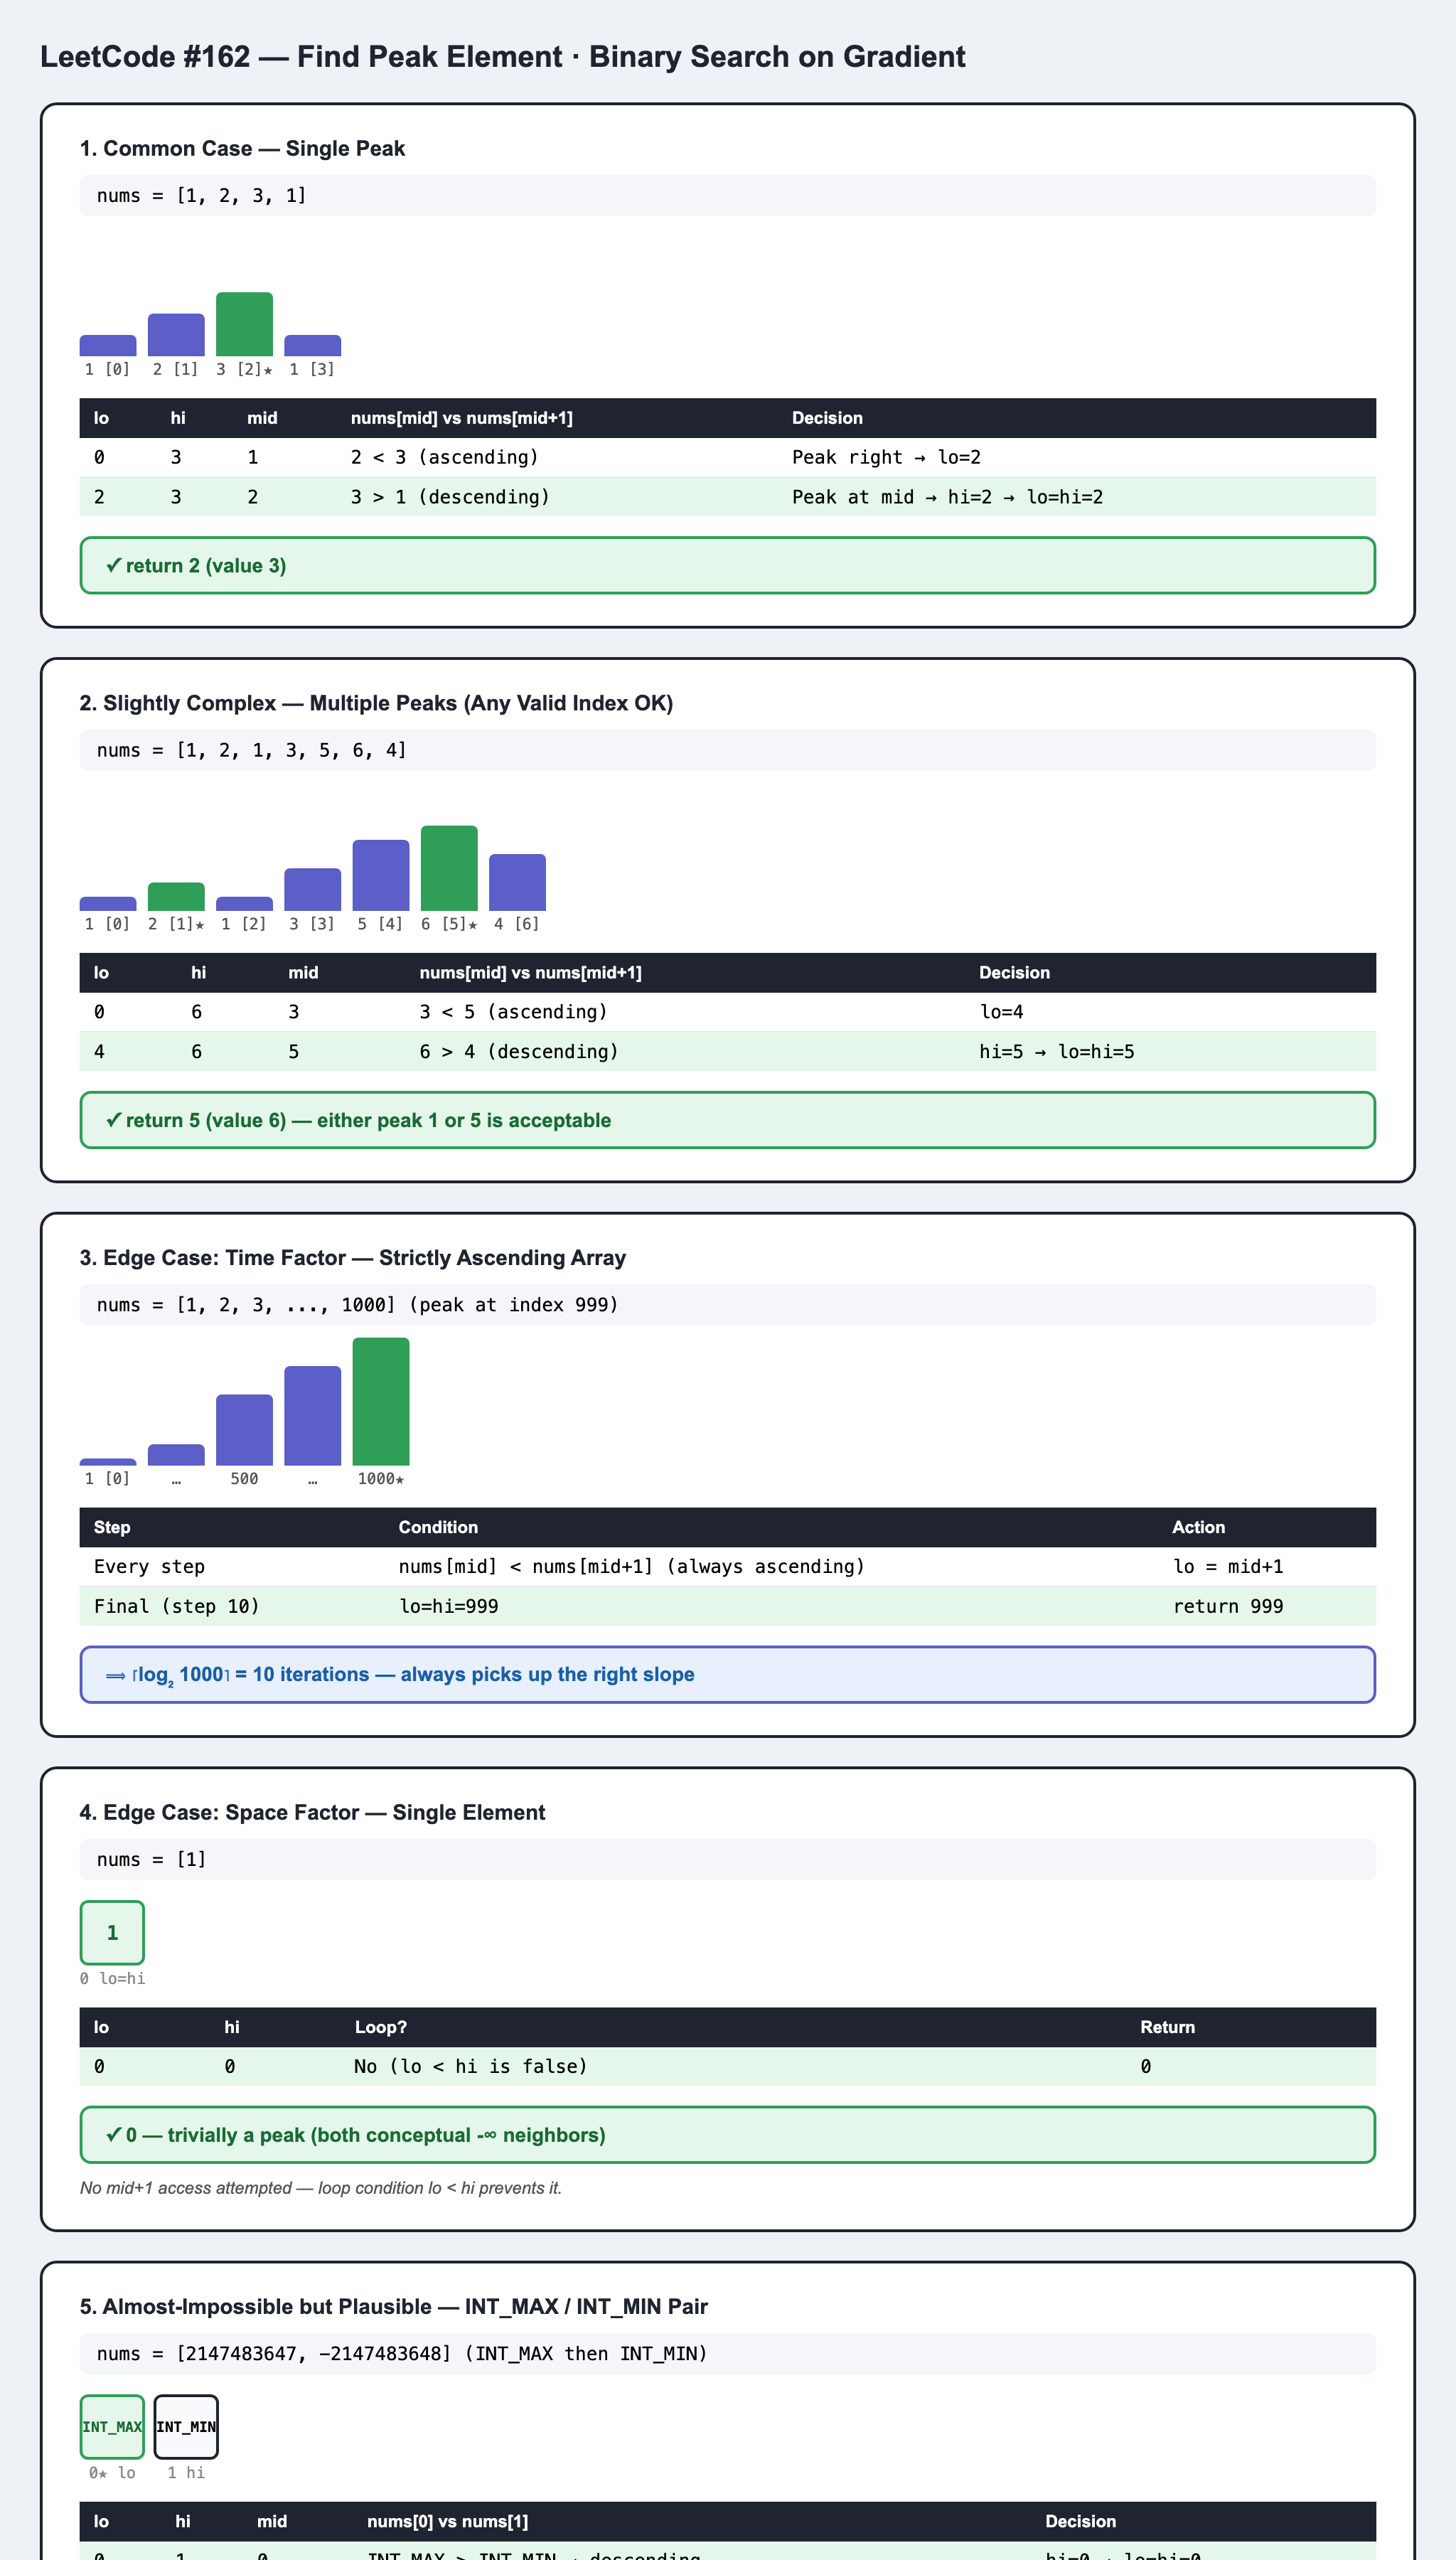